In [51]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict,Annotated

In [52]:
load_dotenv()

True

In [53]:
llm = ChatOpenAI(model="gpt-5-mini", temperature=0.7)

In [54]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [55]:
def chat_node(state: ChatState) -> ChatState:
    # Get the messages from the state
    messages = state.get('messages', [])
    
    # Call the LLM with the messages
    response = llm.invoke(messages)
    
    # Append the response to the messages
    messages.append(response)
    
    # Return the updated state
    return {'messages': messages}

In [56]:
graph = StateGraph(ChatState)

In [57]:
graph.add_node('chat_node',chat_node)
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

In [58]:
chatbot = graph.compile()

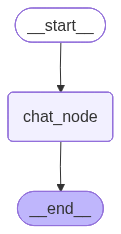

In [59]:
chatbot

In [60]:
initial_state = {
    'messages': [HumanMessage(content='What is Object Oriented Programming?')]
    }
response = chatbot.invoke(initial_state)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}